# Etapa 4 - Correlação entre Variáveis

Nesta etapa será analisada a relação entre as variáveis climáticas do conjunto de dados.

Serão calculados:

- Coeficientes de correlação de Pearson
- Modelos de regressão linear

Os pares analisados serão:

- Radiação × Temperatura
- Radiação × Evapotranspiração
- Radiação × Precipitação
- Temperatura × Evapotranspiração
- Temperatura × Precipitação
- Precipitação × Evapotranspiração

O objetivo é identificar quais variáveis apresentam maior relação com a radiação solar, fator importante para o potencial fotovoltaico.

In [160]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [137]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [138]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [139]:
dados = pd.read_excel(file_path, sheet_name="dados")

In [140]:
dados.head()

,Data,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
0,1984-01-01,0.989776,0.518743,25.419519,211.801254
1,1984-01-02,0.166336,0.587044,26.399133,204.752853
2,1984-01-03,0.256648,0.419522,26.202539,217.430527
3,1984-01-04,0.000000,0.478503,26.720331,222.075912
4,1984-01-05,0.000000,0.374592,27.286249,220.100525


In [141]:
dados.columns.tolist()



['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração ',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [142]:
dados.columns = dados.columns.str.strip()

In [143]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [144]:
dados_correlacao = dados[[
    "W/m² - Radiação",
    "C° - Temperatura Média",
    "mm/dia - Precipitação",
    "mm/dia - Evapotranspiração"
]]

In [145]:
dados_correlacao.head()

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação,mm/dia - Evapotranspiração
0,211.801254,25.419519,0.989776,0.518743
1,204.752853,26.399133,0.166336,0.587044
2,217.430527,26.202539,0.256648,0.419522
3,222.075912,26.720331,0.000000,0.478503
4,220.100525,27.286249,0.000000,0.374592


In [146]:
correlacao = dados_correlacao.corr(method="pearson")

correlacaocorrelacao = dados_correlacao.corr(method="pearson")

correlacao

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação,mm/dia - Evapotranspiração
W/m² - Radiação,1.000000,0.598958,-0.526685,-0.243539
C° - Temperatura Média,0.598958,1.000000,-0.231151,-0.360603
mm/dia - Precipitação,-0.526685,-0.231151,1.000000,0.159936
mm/dia - Evapotranspiração,-0.243539,-0.360603,0.159936,1.000000


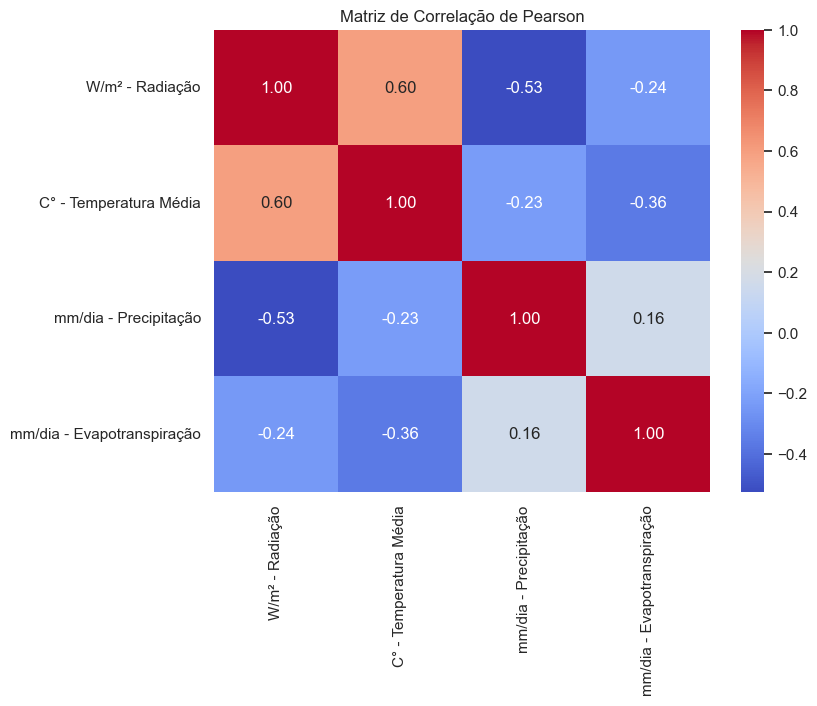

In [147]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação de Pearson")
plt.show()

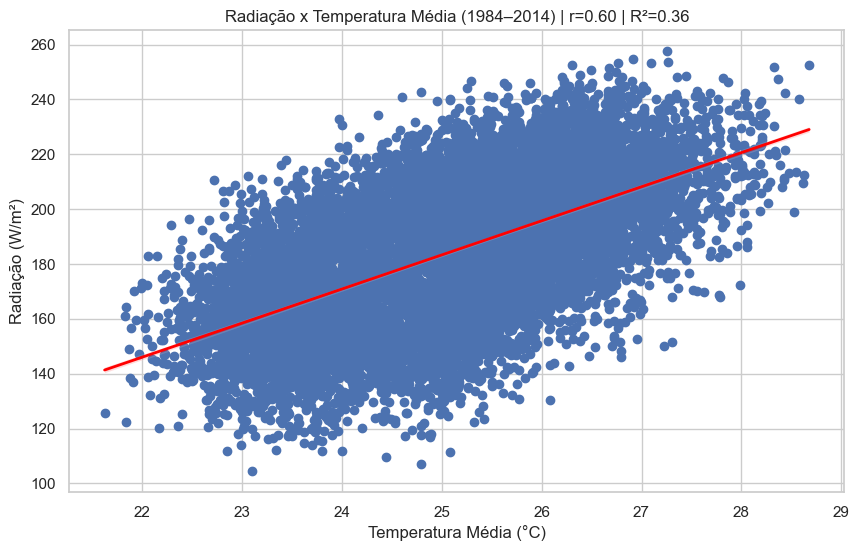

In [148]:
# 1) Radiação x Temperatura Média
x = dados["C° - Temperatura Média"]
y = dados["W/m² - Radiação"]

r = x.corr(y)

X = x.to_frame()
modelo = LinearRegression()
modelo.fit(X, y)
r2 = modelo.score(X, y)

sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 1},  # pontos opacos
    line_kws={"color": "red", "linewidth": 2}
 )

plt.xlabel("Temperatura Média (°C)")
plt.ylabel("Radiação (W/m²)")
plt.title(f"Radiação x Temperatura Média (1984–2014) | r={r:.2f} | R²={r2:.2f}")
plt.show()

**Interpretação (Radiação × Temperatura Média):**
- O sinal de `r` indica a direção: `r>0` significa que, em média, temperaturas mais altas tendem a ocorrer junto com maior radiação; `r<0` indicaria o contrário.
- A magnitude de `r` e o `R²` no título mostram a força do ajuste linear: `R²` é a fração da variabilidade da radiação explicada pela temperatura (neste modelo simples).
- Em termos de potencial fotovoltaico (proxy pela radiação), uma associação positiva sugere que períodos mais quentes tendem a coincidir com maior disponibilidade energética; como é relação estatística, não implica causalidade direta.

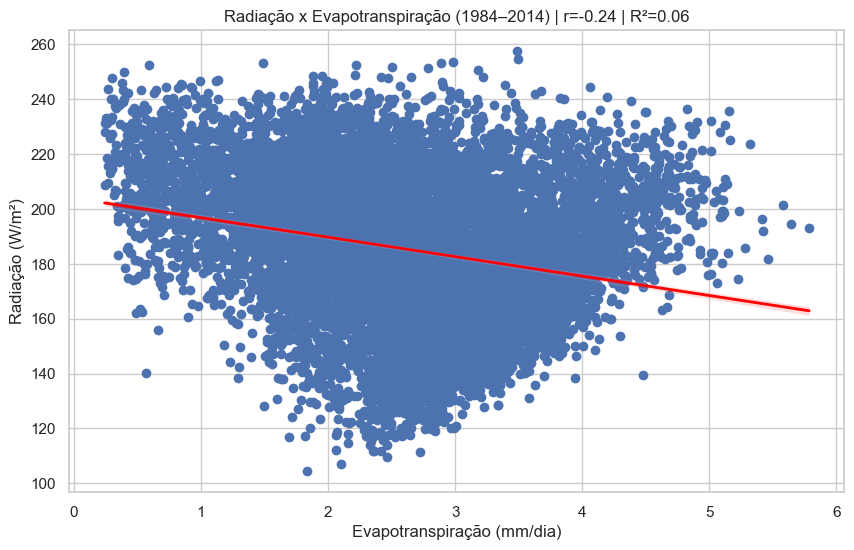

In [149]:
# 2) Radiação x Evapotranspiração
x = dados["mm/dia - Evapotranspiração"]
y = dados["W/m² - Radiação"]

r = x.corr(y)

X = x.to_frame()
modelo = LinearRegression()
modelo.fit(X, y)
r2 = modelo.score(X, y)

sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 1},  # pontos opacos
    line_kws={"color": "red", "linewidth": 2}
 )

plt.xlabel("Evapotranspiração (mm/dia)")
plt.ylabel("Radiação (W/m²)")
plt.title(f"Radiação x Evapotranspiração (1984–2014) | r={r:.2f} | R²={r2:.2f}")
plt.show()

**Interpretação (Radiação × Evapotranspiração):**
- O sinal de `r` mostra se maior evapotranspiração tende a vir acompanhada de maior (`r>0`) ou menor (`r<0`) radiação no mesmo período.
- `R²` indica quanto um modelo linear simples com evapotranspiração consegue explicar a variação da radiação: valores baixos sugerem que a evapotranspiração, sozinha, não é um bom preditor linear da radiação.
- Como evapotranspiração depende de múltiplos fatores (energia disponível, umidade, vento), a relação com radiação pode ser fraca e/ou não linear.

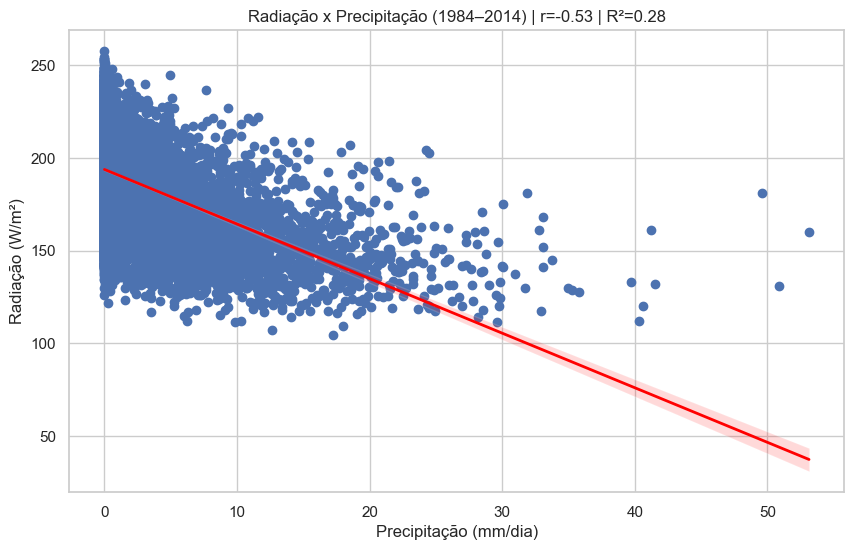

In [150]:
# 3) Radiação x Precipitação
x = dados["mm/dia - Precipitação"]
y = dados["W/m² - Radiação"]

r = x.corr(y)

X = x.to_frame()
modelo = LinearRegression()
modelo.fit(X, y)
r2 = modelo.score(X, y)

sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 1},  # pontos opacos
    line_kws={"color": "red", "linewidth": 2}
 )

plt.xlabel("Precipitação (mm/dia)")
plt.ylabel("Radiação (W/m²)")
plt.title(f"Radiação x Precipitação (1984–2014) | r={r:.2f} | R²={r2:.2f}")
plt.show()

**Interpretação (Radiação × Precipitação):**
- Se `r<0`, períodos mais chuvosos tendem a coincidir com menor radiação, o que é consistente com maior nebulosidade reduzindo a irradiância disponível.
- O `R²` indica o quanto a precipitação explica a variação da radiação no modelo linear simples; mesmo com `r` moderado, `R²` pode não ser alto por causa de dispersão e outros controles atmosféricos.
- Para potencial fotovoltaico, essa relação ajuda a justificar sazonalidade/variabilidade: meses/dias mais chuvosos podem reduzir a geração por queda de radiação.

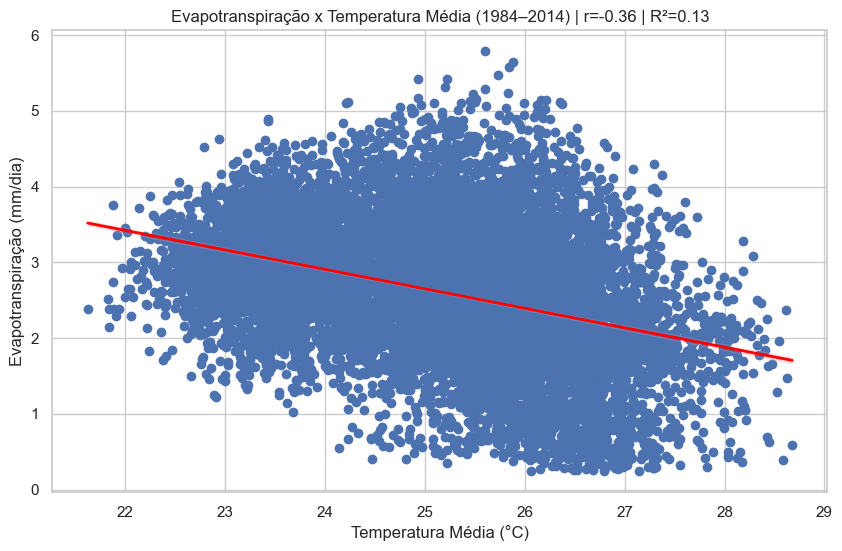

In [151]:
# 4) Evapotranspiração x Temperatura Média
x = dados["C° - Temperatura Média"]
y = dados["mm/dia - Evapotranspiração"]

r = x.corr(y)

X = x.to_frame()
modelo = LinearRegression()
modelo.fit(X, y)
r2 = modelo.score(X, y)

sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 1},  # pontos opacos
    line_kws={"color": "red", "linewidth": 2}
 )

plt.xlabel("Temperatura Média (°C)")
plt.ylabel("Evapotranspiração (mm/dia)")
plt.title(f"Evapotranspiração x Temperatura Média (1984–2014) | r={r:.2f} | R²={r2:.2f}")
plt.show()

**Interpretação (Evapotranspiração × Temperatura Média):**
- Com `r>0`, dias/meses mais quentes tendem a apresentar maior evapotranspiração, coerente com maior demanda evaporativa.
- O `R²` quantifica o quanto a temperatura, sozinha, explica a evapotranspiração de forma linear; valores modestos sugerem influência importante de umidade, vento e radiação.
- Esta relação é útil para contextualizar balanço hídrico/energia, mesmo não sendo diretamente “potencial FV”.

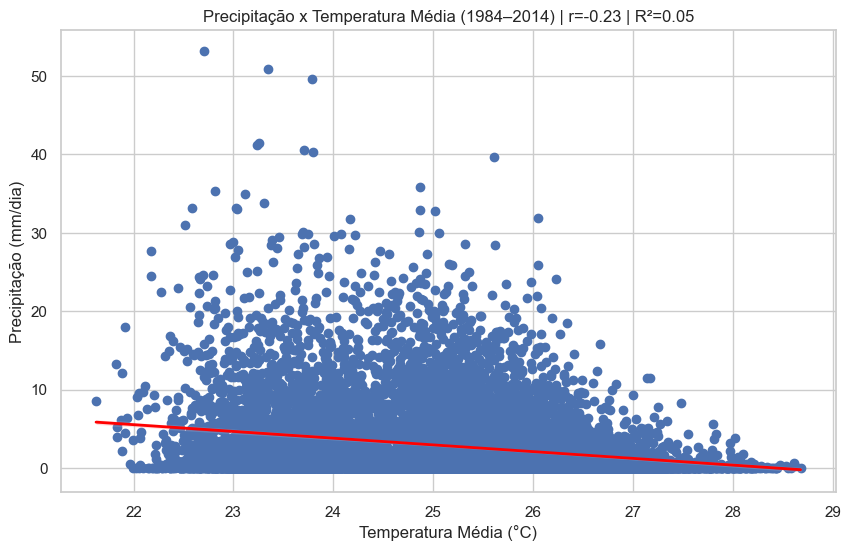

In [152]:
# 5) Precipitação x Temperatura Média
x = dados["C° - Temperatura Média"]
y = dados["mm/dia - Precipitação"]

r = x.corr(y)

X = x.to_frame()
modelo = LinearRegression()
modelo.fit(X, y)
r2 = modelo.score(X, y)

sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 1},  # pontos opacos
    line_kws={"color": "red", "linewidth": 2}
 )

plt.xlabel("Temperatura Média (°C)")
plt.ylabel("Precipitação (mm/dia)")
plt.title(f"Precipitação x Temperatura Média (1984–2014) | r={r:.2f} | R²={r2:.2f}")
plt.show()

**Interpretação (Precipitação × Temperatura Média):**
- Se `|r|` é pequeno e `R²` baixo, a relação linear entre precipitação e temperatura é fraca, indicando alta variabilidade e influência de processos convectivos/sinóticos.
- O sinal de `r` (positivo/negativo) indica a tendência média, mas a dispersão pode ser grande mesmo assim.
- Para o estudo de energia solar, essa relação é mais indireta: ajuda a entender o regime climático que pode afetar nebulosidade e, portanto, radiação.

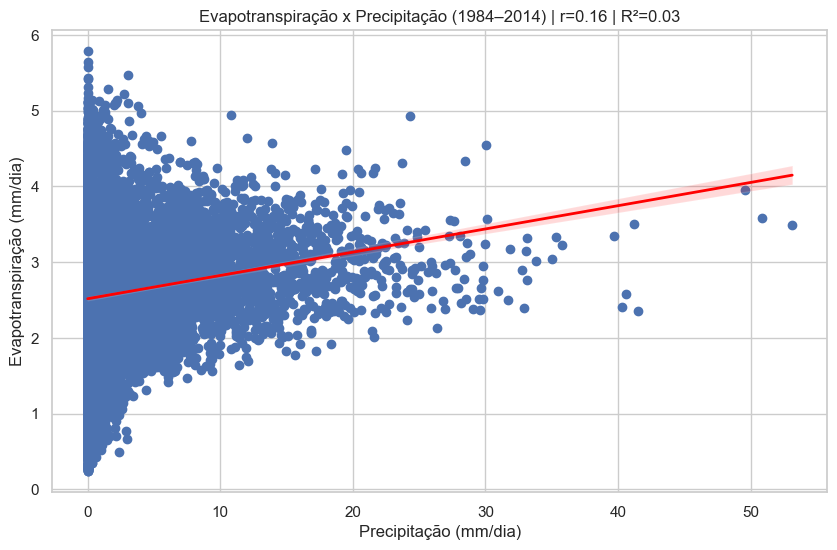

In [153]:
# 6) Evapotranspiração x Precipitação
x = dados["mm/dia - Precipitação"]
y = dados["mm/dia - Evapotranspiração"]

r = x.corr(y)

X = x.to_frame()
modelo = LinearRegression()
modelo.fit(X, y)
r2 = modelo.score(X, y)

sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 1},  # pontos opacos
    line_kws={"color": "red", "linewidth": 2}
 )

plt.xlabel("Precipitação (mm/dia)")
plt.ylabel("Evapotranspiração (mm/dia)")
plt.title(f"Evapotranspiração x Precipitação (1984–2014) | r={r:.2f} | R²={r2:.2f}")
plt.show()

**Interpretação (Evapotranspiração × Precipitação):**
- O sinal de `r` indica se períodos mais chuvosos tendem a estar associados a maior ou menor evapotranspiração; muitas vezes a relação pode ser fraca por efeitos contrapostos (mais água disponível vs. menos energia por nebulosidade).
- `R²` baixo sugere que precipitação isoladamente não explica bem a evapotranspiração de forma linear.
- Este gráfico ajuda a interpretar o comportamento conjunto do ciclo hidrológico (água disponível) e da demanda evaporativa.

In [154]:
X = dados[["C° - Temperatura Média"]]
y = dados["W/m² - Radiação"]

modelo_rt = LinearRegression()
modelo_rt.fit(X, y)

print("Coeficiente angular:", modelo_rt.coef_[0])
print("Intercepto:", modelo_rt.intercept_)
print("R²:", modelo_rt.score(X, y))

Coeficiente angular: 12.432745741951289
Intercepto: -127.51450797446745
R²: 0.35875020164262206


In [155]:
X = dados[["mm/dia - Evapotranspiração"]]
y = dados["W/m² - Radiação"]

modelo_re = LinearRegression()
modelo_re.fit(X, y)

print("Coeficiente angular:", modelo_re.coef_[0])
print("Intercepto:", modelo_re.intercept_)
print("R²:", modelo_re.score(X, y))

Coeficiente angular: -7.0922528014380415
Intercepto: 203.9369398807112
R²: 0.0593112347406769


In [156]:
X = dados[["mm/dia - Precipitação"]]
y = dados["W/m² - Radiação"]

modelo_rp = LinearRegression()
modelo_rp.fit(X, y)

print("Coeficiente angular:", modelo_rp.coef_[0])
print("Intercepto:", modelo_rp.intercept_)
print("R²:", modelo_rp.score(X, y))

Coeficiente angular: -2.943017055042723
Intercepto: 193.78534896411313
R²: 0.27739662688083544


In [157]:
X = dados[["C° - Temperatura Média"]]
y = dados["mm/dia - Evapotranspiração"]

modelo_te = LinearRegression()
modelo_te.fit(X, y)

print("Coeficiente angular:", modelo_te.coef_[0])
print("Intercepto:", modelo_te.intercept_)
print("R²:", modelo_te.score(X, y))

Coeficiente angular: -0.25703079322301997
Intercepto: 9.075646651658655
R²: 0.13003486537145303


In [158]:
X = dados[["C° - Temperatura Média"]]
y = dados["mm/dia - Precipitação"]

modelo_tp = LinearRegression()
modelo_tp.fit(X, y)

print("Coeficiente angular:", modelo_tp.coef_[0])
print("Intercepto:", modelo_tp.intercept_)
print("R²:", modelo_tp.score(X, y))

Coeficiente angular: -0.858666168358243
Intercepto: 24.444573787488743
R²: 0.05343073340179927


In [159]:
X = dados[["mm/dia - Precipitação"]]
y = dados["mm/dia - Evapotranspiração"]

modelo_pe = LinearRegression()
modelo_pe.fit(X, y)

print("Coeficiente angular:", modelo_pe.coef_[0])
print("Intercepto:", modelo_pe.intercept_)
print("R²:", modelo_pe.score(X, y))

Coeficiente angular: 0.030688233737705947
Intercepto: 2.518501465194418
R²: 0.02557942951618586


## 4. Análise de Correlação entre Variáveis Climáticas

Nesta etapa, foi realizada a análise de correlação entre as variáveis climáticas por meio de dois procedimentos principais:

- **Correlação de Pearson** - mede a força e direção da relação

Serve para medir se duas variáveis andam juntas e em que direção.

- positiva: uma sobe, a outra tende a subir

- negativa: uma sobe, a outra tende a cair

- perto de 0: quase não há relação linear

- perto de 1 ou -1: relação mais forte

Ela ajuda a ver, por exemplo, se quando a temperatura aumenta, a radiação também aumenta, ou se quando a precipitação aumenta, a radiação diminui.


- **Regressão Linear Simples** - cria uma reta para modelar essa relação e ver o poder de explicação

Serve para desenhar uma reta que representa essa relação entre duas variáveis e mostrar o quanto uma pode ajudar a explicar a outra.

Ela ajuda a dizer algo como:

“quando a temperatura aumenta, a radiação tende a aumentar”
“quando a precipitação aumenta, a radiação tende a diminuir”


As relações analisadas foram:

- radiação × temperatura média;
- radiação × evapotranspiração;
- radiação × precipitação;
- temperatura média × evapotranspiração;
- temperatura média × precipitação;
- precipitação × evapotranspiração.

---

## 4.1 Organização dos dados para correlação

Foram selecionadas as seguintes variáveis numéricas do conjunto de dados:

- **W/m² - Radiação**
- **C° - Temperatura Média**
- **mm/dia - Precipitação**
- **mm/dia - Evapotranspiração**

Em seguida, foi calculada a **matriz de correlação de Pearson**, que mede a intensidade e a direção da relação linear entre duas variáveis.

---

## 4.2 Matriz de Correlação de Pearson

Os coeficientes encontrados foram:

| Variáveis | Correlação |
|---|---:|
| Radiação × Temperatura Média | 0.598958 |
| Radiação × Precipitação | -0.526685 |
| Radiação × Evapotranspiração | -0.243539 |
| Temperatura Média × Precipitação | -0.231151 |
| Temperatura Média × Evapotranspiração | -0.360603 |
| Precipitação × Evapotranspiração | 0.159936 |

---

## 4.3 Interpretação da matriz de correlação

### a) Radiação × Temperatura Média
A correlação foi **positiva moderada** (**r = 0.598958**).

Isso indica que, em geral, **à medida que a temperatura média aumenta, a radiação também tende a aumentar**. Trata-se da relação linear mais forte observada entre as variáveis analisadas.

### b) Radiação × Precipitação
A correlação foi **negativa moderada** (**r = -0.526685**).

Isso sugere que **dias ou períodos com maior precipitação tendem a apresentar menor radiação solar**, o que faz sentido climatologicamente, já que maior ocorrência de chuva costuma estar associada à maior nebulosidade e menor incidência de radiação.

### c) Radiação × Evapotranspiração
A correlação foi **negativa fraca** (**r = -0.243539**).

Essa relação indica uma tendência inversa pouco intensa entre as duas variáveis. Portanto, apesar de existir uma inclinação negativa, ela não é forte o suficiente para indicar uma associação linear expressiva.

### d) Temperatura Média × Precipitação
A correlação foi **negativa fraca** (**r = -0.231151**).

Isso mostra que temperaturas mais altas tendem a estar associadas a menores níveis de precipitação, mas a intensidade dessa relação é baixa.

### e) Temperatura Média × Evapotranspiração
A correlação foi **negativa fraca a moderada** (**r = -0.360603**).

Essa associação sugere que, no conjunto analisado, o aumento da temperatura média não veio acompanhado de aumento proporcional da evapotranspiração, indicando uma relação linear inversa de baixa intensidade.

### f) Precipitação × Evapotranspiração
A correlação foi **positiva fraca** (**r = 0.159936**).

Isso indica que existe apenas uma leve tendência de aumento conjunto entre precipitação e evapotranspiração, mas a relação linear é muito pequena.

---

## 4.4 Interpretação do heatmap

O heatmap facilita a visualização dessas relações:

- valores **positivos** aparecem em tons quentes;
- valores **negativos** aparecem em tons frios;
- quanto mais próximo de **1** ou **-1**, mais forte é a relação linear;
- quanto mais próximo de **0**, mais fraca é a relação linear.

Pelo gráfico, fica evidente que:

- a **maior associação positiva** foi entre **radiação e temperatura média**;
- a **maior associação negativa** foi entre **radiação e precipitação**;
- as demais relações apresentaram intensidade fraca.

---

## 4.5 Regressão Linear Simples

Além da correlação, foi ajustado um modelo de **regressão linear simples** para cada par de variáveis. Esse procedimento permite avaliar:

- a direção da relação por meio do **coeficiente angular**;
- o valor esperado da variável resposta quando a variável explicativa é zero por meio do **intercepto**;
- o quanto a variação da variável resposta é explicada pelo modelo, por meio do **R²**.

---

## 4.6 Resultados da regressão linear

### a) Radiação × Temperatura Média

**Modelo ajustado:**
- coeficiente angular = **12.432745741951289**
- intercepto = **-127.5145079446745**
- R² = **0.35875020164262206**

### Interpretação
O coeficiente angular positivo indica que **o aumento da temperatura média está associado ao aumento da radiação**. O valor de **R² ≈ 0.359** mostra que cerca de **35,9% da variação da radiação** pode ser explicada pela temperatura média nesse modelo linear.

Entre todos os pares analisados, este foi o modelo com melhor poder explicativo.

---

### b) Radiação × Evapotranspiração

**Modelo ajustado:**
- coeficiente angular = **-7.0922528014380415**
- intercepto = **203.9369398807112**
- R² = **0.0593112347406769**

### Interpretação
O coeficiente angular negativo indica uma tendência de redução da radiação com o aumento da evapotranspiração. No entanto, o **R² muito baixo** mostra que essa relação linear explica apenas cerca de **5,9% da variabilidade da radiação**, sendo portanto uma associação fraca.

---

### c) Radiação × Precipitação

**Modelo ajustado:**
- coeficiente angular = **-2.943017055042723**
- intercepto = **193.78534896411313**
- R² = **0.27739662688083544**

### Interpretação
O coeficiente angular negativo confirma a tendência observada na correlação: **quanto maior a precipitação, menor tende a ser a radiação**. O valor de **R² ≈ 0.277** indica que aproximadamente **27,7% da variação da radiação** pode ser explicada pela precipitação.

Essa foi a segunda relação linear mais relevante da análise.

---

### d) Temperatura Média × Evapotranspiração

**Modelo ajustado:**
- coeficiente angular = **-0.25703079322301997**
- intercepto = **9.075646651658655**
- R² = **0.13003486537145303**

### Interpretação
O coeficiente angular negativo indica que, no conjunto de dados, o aumento da temperatura média esteve associado a uma leve redução da evapotranspiração. O **R² ≈ 0.130** mostra que o modelo explica apenas **13,0% da variação da evapotranspiração**, o que representa baixo poder explicativo.

---

### e) Temperatura Média × Precipitação

**Modelo ajustado:**
- coeficiente angular = **-0.858666168358243**
- intercepto = **24.444573787488743**
- R² = **0.05343073340179927**

### Interpretação
O coeficiente angular negativo mostra uma leve tendência de diminuição da precipitação com o aumento da temperatura média. Entretanto, o valor de **R² ≈ 0.053** indica que essa relação linear é muito fraca.

---

### f) Precipitação × Evapotranspiração

**Modelo ajustado:**
- coeficiente angular = **0.030688233737705947**
- intercepto = **2.518501465194418**
- R² = **0.02557942951618586**

### Interpretação
O coeficiente angular positivo indica uma leve tendência de aumento da evapotranspiração com o aumento da precipitação. Contudo, como o **R² ≈ 0.026**, esse modelo praticamente não explica a variabilidade da evapotranspiração.

---

## 4.7 Interpretação dos gráficos de dispersão com linha de regressão

Os gráficos de dispersão confirmam visualmente os padrões observados na matriz de correlação e nos modelos lineares.

### Radiação × Temperatura Média
Observa-se uma **nuvem de pontos com inclinação positiva**, mostrando que valores mais altos de temperatura tendem a acompanhar valores mais altos de radiação.

### Radiação × Evapotranspiração
A dispersão dos pontos é ampla e a inclinação da reta é levemente negativa, indicando **relação fraca e pouco explicativa**.

### Radiação × Precipitação
A reta possui inclinação negativa mais evidente. Isso mostra que **a radiação tende a diminuir quando a precipitação aumenta**, coerente com o comportamento climático esperado.

### Temperatura Média × Evapotranspiração
A inclinação negativa existe, mas a nuvem de pontos continua bastante espalhada, reforçando que a relação linear é fraca.

### Temperatura Média × Precipitação
Há leve tendência negativa, porém com forte dispersão dos dados e baixa capacidade explicativa.

### Precipitação × Evapotranspiração
A reta apresenta leve inclinação positiva, mas o espalhamento dos pontos indica associação linear muito pequena.

---

## 4.8 Síntese dos principais achados

A análise de correlação e regressão mostrou que:

- **radiação e temperatura média** apresentaram a **relação positiva mais forte**;
- **radiação e precipitação** apresentaram a **relação negativa mais importante**;
- as demais associações foram **fracas** e com **baixo poder explicativo**;
- os valores de **R²** indicam que, de modo geral, a maioria das relações lineares entre essas variáveis é limitada;
- as interações climáticas existem, mas nem todas são bem representadas por modelos lineares simples.

---

## 4.9 Conclusão da etapa

Os resultados indicam que a **radiação solar** está mais fortemente associada à **temperatura média** e à **precipitação** do que à evapotranspiração. Em especial:

- o aumento da **temperatura média** tende a acompanhar o aumento da **radiação**;
- o aumento da **precipitação** tende a reduzir a **radiação**;
- as demais relações apresentaram comportamento linear fraco.

No contexto climático do Semiárido Paraibano, esses achados são coerentes com a dinâmica regional, em que:

- períodos mais secos e quentes tendem a favorecer maior disponibilidade de radiação;
- períodos mais chuvosos tendem a reduzir a incidência de radiação devido ao aumento da nebulosidade.

Portanto, a análise de correlação e regressão linear contribui para compreender como as variáveis climáticas se associam entre si e ajuda a interpretar o comportamento do potencial climático e energético da região.